In [1]:
cd /lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO/notebooks/dinostics/

/lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO/notebooks/dinostics


In [2]:
from experiment import NemoExperiment
from matplotlib import colors
from matplotlib import pyplot as plt
import numpy as np
import xarray as xr
import cftime as cft    
import xnemogcm as xn
import xgcm
import cmocean as cm

In [3]:
path_store      = "/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/"
path_scratch    = "/lustre/fsn1/projects/rech/omr/uym68qx/DINO/"
path_work    = "/lustre/fswork/projects/rech/omr/uym68qx/data/"

In [4]:
import matplotlib as mpl

SMALL_SIZE = 15
MEDIUM_SIZE = 15
BIGGER_SIZE = 15
color=['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']
color_blind = mpl.cycler(
    color=color)

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('axes', prop_cycle=color_blind)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Preparing a 1degree restart from the generated fields

In [14]:
batch = 'C2'

In [15]:
soce = np.load(path_work + f'Blandine/{batch}/soce.npy')[4,:,:,:]
toce = np.load(path_work + f'Blandine/{batch}/toce.npy')[4,:,:,:]
ssh = np.load(path_work + f'Blandine/{batch}/ssh.npy')[4,:,:]

In [5]:
exp_1deg = NemoExperiment(
    path=path_scratch,
    experiment_name='Blandine/1deg_restart',
)

In [6]:
exp_1_4deg = NemoExperiment(
    path=path_scratch,
    experiment_name='Blandine/restart25',
)

In [48]:
restart_dummy = exp_1deg.open_restart().load()

In [49]:
nml = exp_1deg.namelist['nameos']
z = exp_1deg.mask.gdept_0.data

rhop  = (
        - nml['rn_a0'] * (1. + 0.5 * nml['rn_lambda1'] * ( toce - 10.) + nml['rn_mu1'] * z) * ( toce - 10.) 
        + nml['rn_b0'] * (1. - 0.5 * nml['rn_lambda2'] * ( soce - 35.) - nml['rn_mu2'] * z) * ( soce - 35.) 
        - nml['rn_nu'] * ( toce - 10.) * ( soce - 35.)
) + 1026

In [50]:
tmask = exp_1deg.mask.tmask.load().data

In [51]:
restart_dummy['tb'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(toce,axis=0))
restart_dummy['tn'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(toce,axis=0))

restart_dummy['sb'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(soce,axis=0))
restart_dummy['sn'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(soce,axis=0))

restart_dummy['sshb'] = (('time_counter', 'y', 'x'), ssh)
restart_dummy['sshn'] = (('time_counter', 'y', 'x'), ssh)

restart_dummy['rhop'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(rhop, axis=0))

In [52]:
restart_dummy.to_netcdf(path_work + 'Blandine/generated_restart_C1.nc', unlimited_dims='time_counter')

In [16]:
exp_1deg = NemoExperiment(
    path=path_scratch,
    experiment_name='Blandine/1deg_restart',
)

/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


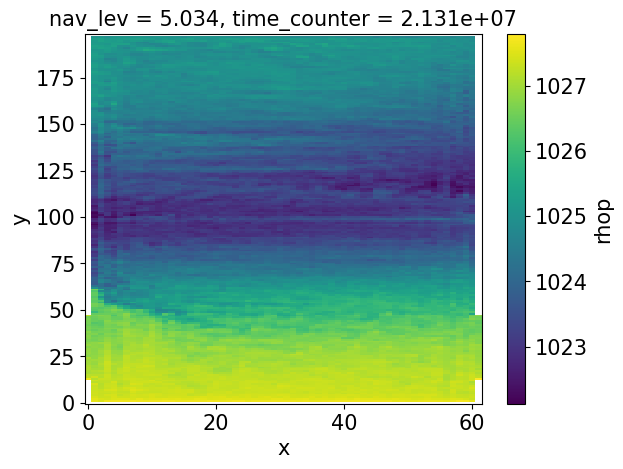

In [17]:
exp_1deg.open_restart().rhop.isel(nav_lev=0).plot()

/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


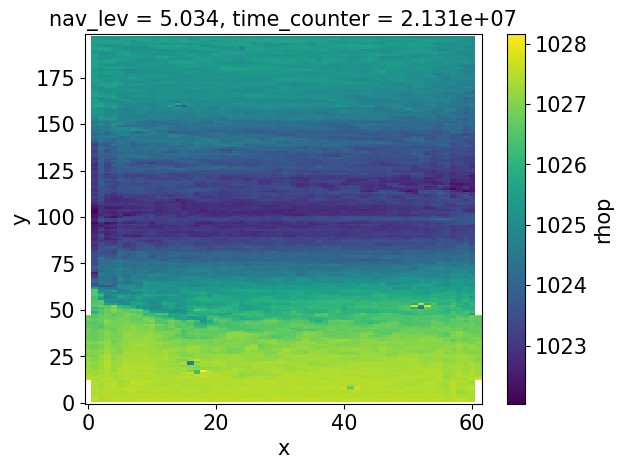

In [7]:
exp_1deg.open_restart().rhop.isel(nav_lev=0).plot()

In [18]:
restart_interpolated = exp_1deg.grid_manipulation.regrid_restart(exp_1_4deg)

/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/dask/array/routines.py:325: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(
/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/dask/array/routines.py:325: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(
/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/dask/array/routines.py:325: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(
/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/dask/array/routines.py:325: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(
/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/dask/array/routines.py:325: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(
/linkhome/rech/

As opposed to the usual usecase of regrid_restart we want to keep everything from the highres restart except T, S, U, V, ssh, rhop. These are replaced by the interpolated values.

In [19]:
restart_new = exp_1_4deg.open_restart().load().copy()

In [20]:
for field in ['tn', 'tb', 'sn', 'sb', 'un', 'ub', 'vn', 'vb', 'rhop']:
    restart_new[field] = (('time_counter', 'nav_lev', 'y', 'x'), restart_interpolated[field].data)
for field in ['sshn', 'sshb']:
    restart_new[field] = (('time_counter', 'y', 'x'), restart_interpolated[field].data)

In [21]:
restart_new = restart_new.fillna(0.)

In [22]:
%%time
restart_new = restart_new.chunk({'time_counter':1, 'y':797, 'x':242, 'nav_lev':36}).compute()

CPU times: user 52.6 s, sys: 2.47 s, total: 55.1 s
Wall time: 21.8 s


In [23]:
restart_new.to_netcdf(path_scratch + 'Blandine/restart25/generated_C2_restart.nc', unlimited_dims='time_counter')

In [12]:
exp_1_4con = NemoExperiment(
    path=path_scratch,
    experiment_name='Etienne_1_4deg_constraint',
    files=['T_3D', 'U_3D', 'V_3D', 'inst_T_3D', 'inst_U_3D', 'inst_V_3D']
)

In [13]:
exp_1_4ref = NemoExperiment(
    path=path_store,
    experiment_name='Dinoffusion/1_4degree/',
    restarts=['restart25', 'restart26', 'restart27', 'restart28', 'restart29'],
    files=['T_3D', 'V_3D', 'U_3D']
)

In [14]:
exp_1_4uncon = NemoExperiment(
    path=path_scratch,
    experiment_name='Etienne_1_4deg_noconstraint',
    files=['T_3D', 'U_3D', 'V_3D', 'inst_T_3D', 'inst_U_3D', 'inst_V_3D']
)

In [15]:
restart_con = exp_1_4con.open_restart().rename({'time_counter':'t', 'nav_lev':'z_c', 'x':'x_c', 'y':'y_c'}).drop_vars('z_c')
restart_uncon = exp_1_4uncon.open_restart().rename({'time_counter':'t', 'nav_lev':'z_c', 'x':'x_c', 'y':'y_c'}).drop_vars('z_c')

/linkhome/rech/genloc01/uym68qx/.conda/envs/dino/lib/python3.9/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [20]:
restart_dummy['var_t_c'] = (['y_c', 'x_c'], var_t_c)
restart_dummy['var_s_c'] = (['y_c', 'x_c'], var_s_c)

In [23]:
restart_dummy['var_t_u'] = (['y_c', 'x_c'], var_t_u)
restart_dummy['var_s_u'] = (['y_c', 'x_c'], var_s_u)

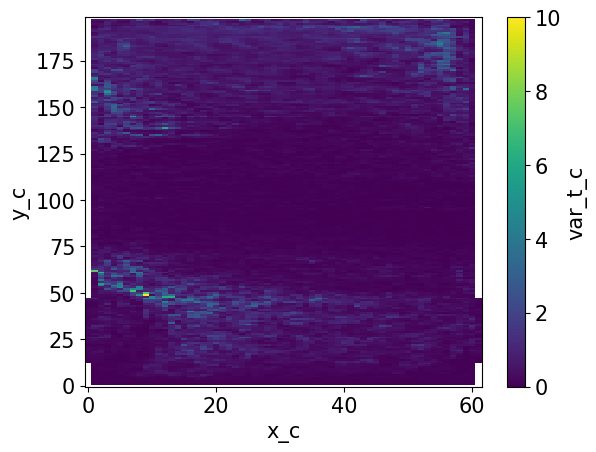

In [22]:
restart_dummy.var_t_c.plot()

## Stratification

In [8]:
sigma2_4_r = exp_1_4ref.diagnostics.get_rho(T=exp_1_4ref.data['T_3D'].toce_inst, S=exp_1_4ref.data['T_3D'].soce_inst, z=0.).where(exp_1_4ref.mask.tmask==1.0)

In [9]:
sigma2_4_ref = sigma2_4_r.mean('x_c')

In [10]:
sigma2_4_ref = sigma2_4_ref.isel(t=slice(-180,-1)).mean('t').compute()

In [11]:
sigma2_c   = exp_1_4con.diagnostics.get_rho(T=restart_con.tn, S=restart_con.sn, z=0.).where(exp_1_4con.mask.tmask==1.0)
sigma2_u = exp_1_4uncon.diagnostics.get_rho(T=restart_uncon.tn, S=restart_uncon.sn, z=0.).where(exp_1_4uncon.mask.tmask==1.0)

In [12]:
sigma2_con = sigma2_c.mean('x_c')
sigma2_uncon = sigma2_u.mean('x_c')

In [13]:
sigma2_con_a   = exp_1_4con.diagnostics.get_rho(T=exp_1_4con.data['T_3D'].toce, S=exp_1_4con.data['T_3D'].soce, z=2000.).where(exp_1_4con.mask.tmask==1.0)
sigma2_uncon_a = exp_1_4uncon.diagnostics.get_rho(T=exp_1_4uncon.data['T_3D'].toce, S=exp_1_4uncon.data['T_3D'].soce, z=2000.).where(exp_1_4uncon.mask.tmask==1.0)

In [14]:
sigma2_con_after = sigma2_con_a.mean('x_c')
sigma2_uncon_after = sigma2_uncon_a.mean('x_c')

In [15]:
sigma2_con_after   = sigma2_con_after.isel(t=slice(-4,None)).mean('t').assign_coords(lat=exp_1_4con.domain.gphit.isel(x_c=10)) - 1000
sigma2_uncon_after = sigma2_uncon_after.isel(t=slice(-4,None)).mean('t').assign_coords(lat=exp_1_4uncon.domain.gphit.isel(x_c=10)) - 1000

In [16]:
sigma2_con   = sigma2_con.assign_coords(lat=exp_1_4con.domain.gphit.isel(x_c=10)) - 1000
sigma2_uncon = sigma2_uncon.assign_coords(lat=exp_1_4uncon.domain.gphit.isel(x_c=10)) - 1000
sigma2_4_ref = sigma2_4_ref.assign_coords(lat=exp_1_4ref.domain.gphit.isel(x_c=10)) - 1000

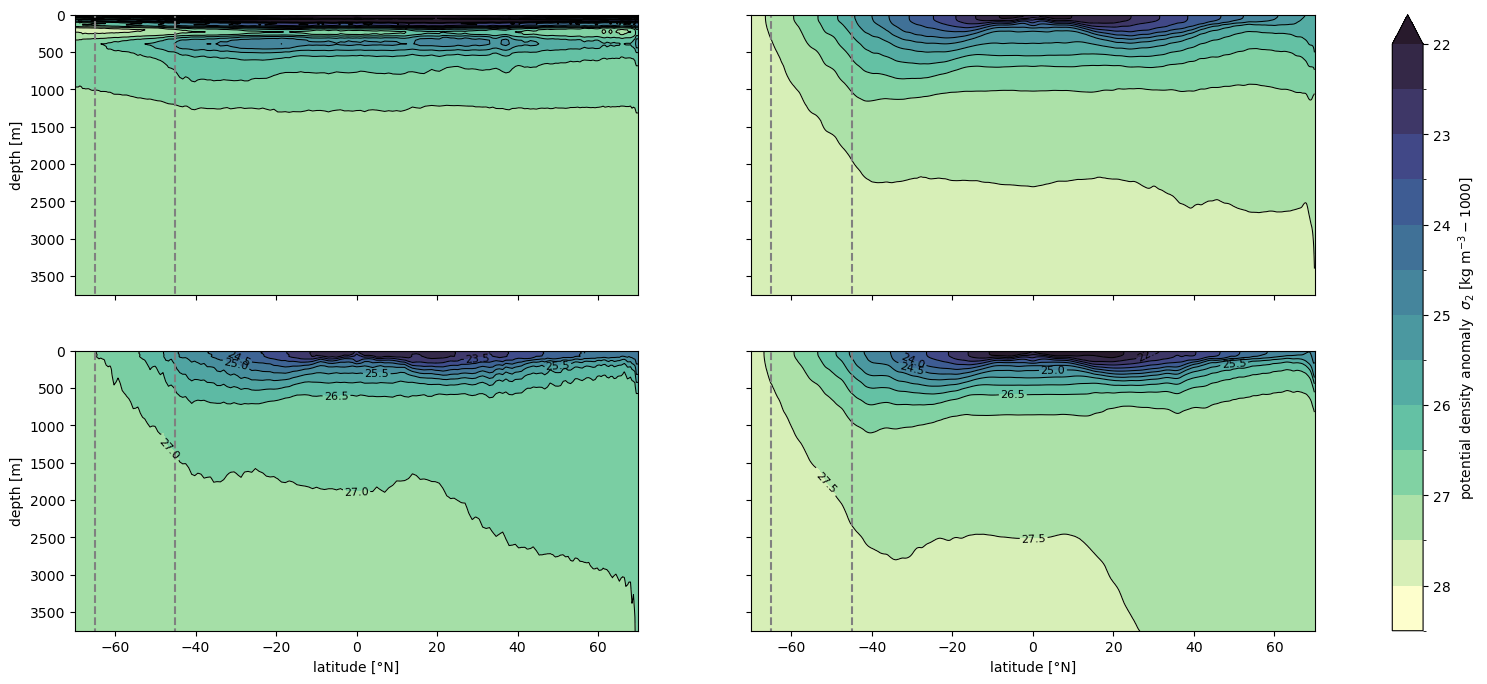

In [17]:
fig_dense, axs = plt.subplots(2,2, figsize=(20,8), sharex=True, sharey=True)
#fig, axs = plt.subplots(3,1, figsize=(15,11), sharex=True, sharey=True)
levels = np.linspace(22.,28.5,14)
a = sigma2_uncon.isel(t=0).plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[0,0], add_colorbar=False, yincrease=False)
contour_2 = sigma2_uncon.isel(t=0).plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[0,0], yincrease=False)
#plt.clabel(contour_2, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
b = sigma2_uncon_after.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[0,1], add_colorbar=False, yincrease=False)
contour_3 = sigma2_uncon_after.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[0,1], yincrease=False)
#sigma2_con.plot.contour(levels=13, colors='k', linewidths=0.75, vmin=1025.6, vmax=1028, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
c = sigma2_con.isel(t=0).plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[1,0], add_colorbar=False, yincrease=False)
contour_2 = sigma2_con.isel(t=0).plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[1,0], yincrease=False)
plt.clabel(contour_2, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
d = sigma2_con_after.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[1,1], add_colorbar=False, yincrease=False)
contour_3 = sigma2_con_after.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[1,1], yincrease=False)
plt.clabel(contour_3, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#c = moc_16.isel(t=slice(-17,-1)).mean('t').plot.contourf(levels=16, vmin=-15, vmax=15, cmap=cm.cm.balance, x='y_f', y='rho', ax=axs[2], add_colorbar=False, yincrease=False)
#moc_16.isel(t=slice(-41,-1)).mean('t').plot.contour(levels=16, colors='k', linewidths=0.75, vmin=-15, vmax=15, x='y_f', y='rho', ax=axs[2], yincrease=False)
cbar1 = fig_dense.colorbar(a, ax=axs[:3], label=r'potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
axs[0,0].set_ylabel(r'depth [m]')
axs[1,0].set_ylabel(r'depth [m]')
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,0].set_xlabel('')
axs[1,0].set_xlabel(r'latitude [°N]')
axs[0,1].set_xlabel('')
axs[1,1].set_xlabel(r'latitude [°N]')

axs[0,0].set_title('')
axs[1,0].set_title('')
axs[0,1].set_title('')
axs[1,1].set_title('')
axs[0,0].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[0,0].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1,0].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1,0].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[0,1].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[0,1].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1,1].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1,1].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
#plt.subplots_adjust(hspace=0.1)
axs[0,0].set_ylim(3750, 0)
axs[1,0].set_ylim(3750, 0)
axs[0,1].set_ylim(3750, 0)
axs[1,1].set_ylim(3750, 0)
#axs[0].text(-0.0, 1.1, 'a)', transform=axs[0].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
#axs[0].text(0.21, 1.1, 'reference', transform=axs[0].transAxes, fontsize=18, va='top', ha='right')
#axs[1].text(-0.0, 1.1, 'b)', transform=axs[1].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
#axs[1].text(0.34, 1.1, 'generated state', transform=axs[1].transAxes, fontsize=18, va='top', ha='right')
#axs[2].text(-0.0, 1.1, 'c)', transform=axs[2].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
#axs[2].text(0.52, 1.1, 'after 10 years simulation', transform=axs[2].transAxes, fontsize=18, va='top', ha='right')
cbar1.ax.invert_yaxis()

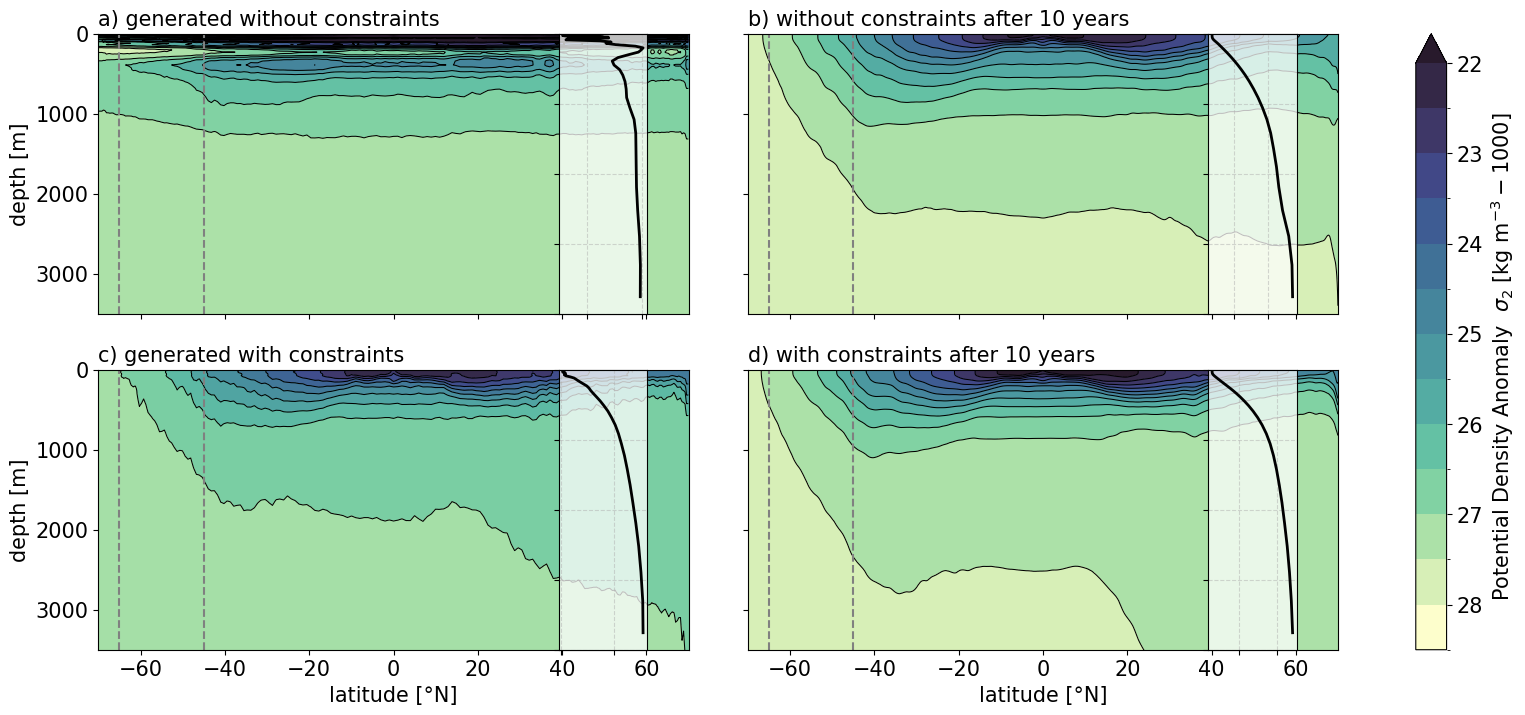

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig_dense_gen, axs = plt.subplots(2, 2, figsize=(20, 8), sharex=True, sharey=True, gridspec_kw = {'hspace':0.2, 'wspace':0.1})
levels = np.linspace(22., 28.5, 14)

row_headers = ["with constraint", "no constraint"]
col_headers = ["generated fields", "after 10 years of simulation"]

def plot_main_and_inset(ax, data, title):
    # Main contour plot
    contourf = data.plot.contourf(levels=levels, cmap=cm.deep_r, x='lat', y='gdept_1d', ax=ax, add_colorbar=False, yincrease=False)
    contour = data.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=ax, yincrease=False)
    #ax.clabel(contour, fmt="%.1f", inline=True, fontsize=8)

    # Vertical dashed lines
    ax.axvline(x=-65, color='gray', linestyle='dashed')
    ax.axvline(x=-45, color='gray', linestyle='dashed')
    ax.set_title('')
    ax.set_title(title, loc='left')
    ax.set_ylim(3500,0)

    # Compute x-average between lat indices
    lat_vals = data.lat.values
    idx_min = np.argmin(np.abs(lat_vals + 65))  # Find index for -65
    idx_max = np.argmin(np.abs(lat_vals + 45))  # Find index for -45
    subset = data.isel(y_c=slice(idx_min, idx_max)).mean(dim='y_c')

    # Inset plot (on the right)
    inset_ax = inset_axes(ax, width="15%", height="100%", loc='right', borderpad=2)
    inset_ax.plot(subset, subset['gdept_1d'], color='black', linewidth=2)
    inset_ax.patch.set_alpha(0.75)
    
    # **Ensure y-axis matches main plot**
    inset_ax.set_ylim(ax.get_ylim())  
    inset_ax.set_yticks(ax.get_yticks())  
    inset_ax.set_yticklabels([])  # Remove y labels for clarity
    inset_ax.set_xticklabels([])  # Remove x labels
    inset_ax.grid(True, linestyle="--", alpha=0.5)


    return contourf

# Apply function to all subplots
a = plot_main_and_inset(axs[0, 0], sigma2_uncon.isel(t=0), title='a) generated without constraints')
b = plot_main_and_inset(axs[0, 1], sigma2_uncon_after, title='b) without constraints after 10 years')
c = plot_main_and_inset(axs[1, 0], sigma2_con.isel(t=0), title='c) generated with constraints')
d = plot_main_and_inset(axs[1, 1], sigma2_con_after, title='d) with constraints after 10 years')

# Shared colorbar
cbar1 = fig_dense_gen.colorbar(a, ax=axs, label=r'Potential Density Anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
cbar1.ax.invert_yaxis()

# Labels
# i=0
# j=0
for ax in axs[:, 0]:
    ax.set_ylabel("depth [m]")
for ax in axs[-1, :]:
    ax.set_xlabel("latitude [°N]")
for ax in axs[:, 1]:
    ax.set_ylabel("")
for ax in axs[0, :]:
    ax.set_xlabel("")


plt.show()


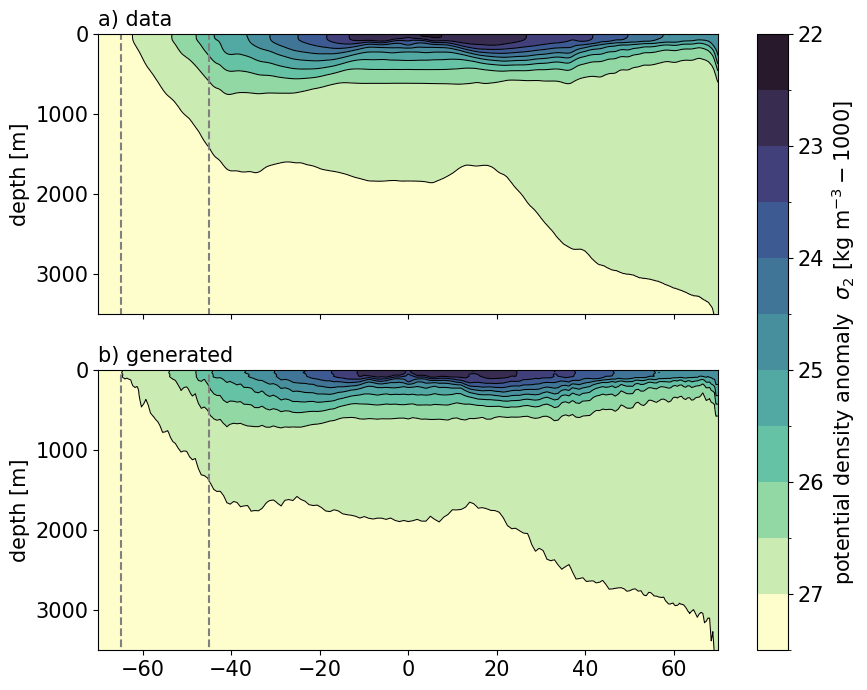

In [114]:
fig_dense, axs = plt.subplots(2,1, figsize=(10,8), sharex=True, sharey=True)
#fig, axs = plt.subplots(3,1, figsize=(15,11), sharex=True, sharey=True)
levels = np.linspace(22,27.5,12)
a = sigma2_4_ref.plot.contourf(levels=levels, cmap=cm.deep_r, x='lat', y='gdept_1d', ax=axs[0], add_colorbar=False, yincrease=False)
contour_1 = sigma2_4_ref.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
#plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#sigma2_con.plot.contour(levels=13, colors='k', linewidths=0.75, vmin=1025.6, vmax=1028, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
b = sigma2_con.isel(t=0).plot.contourf(levels=levels, cmap=cm.deep_r, x='lat', y='gdept_1d', ax=axs[1], add_colorbar=False, yincrease=False)
contour_2 = sigma2_con.isel(t=0).plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[1], yincrease=False)
#plt.clabel(contour_2, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#c = sigma2_uncon_after.plot.contourf(levels=levels, cmap=cm.deep_r, x='lat', y='gdept_1d', ax=axs[2], add_colorbar=False, yincrease=False)
#contour_3 = sigma2_uncon_after.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[2], yincrease=False)
#plt.clabel(contour_3, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#c = moc_16.isel(t=slice(-17,-1)).mean('t').plot.contourf(levels=16, vmin=-15, vmax=15, cmap=cm.cm.balance, x='y_f', y='rho', ax=axs[2], add_colorbar=False, yincrease=False)
#moc_16.isel(t=slice(-41,-1)).mean('t').plot.contour(levels=16, colors='k', linewidths=0.75, vmin=-15, vmax=15, x='y_f', y='rho', ax=axs[2], yincrease=False)
cbar1 = fig_dense.colorbar(a, ax=axs[:3], label=r'potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
axs[1].set_ylabel(r'depth [m]')
axs[0].set_ylabel(r'depth [m]')

axs[1].set_xlabel('')
axs[0].set_xlabel('')

axs[0].set_title('', loc='center')
axs[1].set_title('', loc='center')
axs[0].set_title('a) data', loc='left')
axs[1].set_title('b) generated', loc='left')

axs[0].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[0].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
#plt.subplots_adjust(hspace=0.1)
axs[0].set_facecolor("lightgray")
axs[1].set_facecolor("lightgray")
axs[0].set_ylim(3500,0)
axs[1].set_ylim(3500,0)

cbar1.ax.invert_yaxis()

In [19]:
volume = exp_1_4con.mask.e3t_0 * exp_1_4con.mask.e2t* exp_1_4con.mask.e1t

In [20]:
V = (volume * exp_1_4con.mask.tmask).sum(['x_c', 'y_c', 'z_c'])

In [25]:
unstable_u = ((sigma2_u.diff('z_c') <0.0 ) * volume * exp_1_4uncon.mask.tmask).sum(['x_c', 'y_c', 'z_c'])
unstable_c = ((sigma2_c.diff('z_c') <0.0 ) * volume * exp_1_4con.mask.tmask).sum(['x_c', 'y_c', 'z_c'])
unstable_r = ((sigma2_4_r.isel(t=-1).diff('z_c') <0.0 ) * volume * exp_1_4ref.mask.tmask).sum(['x_c', 'y_c', 'z_c'])

In [29]:
print('Reference: ' + str((unstable_r / V).values * 100))
print('With constraint: ' + str((unstable_c / V).values[0] * 100))
print('Without constraint: ' + str((unstable_u / V).values[0] * 100))

Reference: 0.007891580025898293
With constraint: 1.7223453149199486
Without constraint: 11.32962480187416


In [54]:
t_c = restart_con.tn.assign_coords(lon_n=restart_con.lon-60).isel(t=0)
t_u = restart_uncon.tn.assign_coords(lon_n=restart_uncon.lon-60).isel(t=0)
t_r = exp_1_4ref.data['T_3D'].toce_inst.isel(t=-1).assign_coords(lon_n=exp_1_4ref.mask.glamt-60)

s_c = restart_con.sn.assign_coords(lon_n=restart_con.lon-60).isel(t=0)
s_u = restart_uncon.sn.assign_coords(lon_n=restart_uncon.lon-60).isel(t=0)
s_r = exp_1_4ref.data['T_3D'].soce_inst.isel(t=-1).assign_coords(lon_n=exp_1_4ref.mask.glamt-60)

In [55]:
t_c.isel(z_c=0).where(exp_1_4ref.mask.tmask.isel(z_c=0)==1.0)

<xarray.DataArray 'tn' (y_c: 797, x_c: 242)>
dask.array<where, shape=(797, 242), dtype=float32, chunksize=(797, 242), chunktype=numpy.ndarray>
Coordinates:
    t         float32 1.339e+07
    lon       (y_c, x_c) float64 -0.125 0.125 0.375 0.625 ... 59.62 59.88 60.12
    lat       (y_c, x_c) float64 -70.02 -70.02 -70.02 ... 70.02 70.02 70.02
    lon_n     (y_c, x_c) float64 -60.12 -59.88 -59.62 ... -0.375 -0.125 0.125
  * x_c       (x_c) int64 0 1 2 3 4 5 6 7 8 ... 234 235 236 237 238 239 240 241
  * y_c       (y_c) int64 0 1 2 3 4 5 6 7 8 ... 789 790 791 792 793 794 795 796
    glamt     (y_c, x_c) float64 dask.array<chunksize=(797, 242), meta=np.ndarray>
    gphit     (y_c, x_c) float64 dask.array<chunksize=(797, 242), meta=np.ndarray>
    gdept_1d  float64 dask.array<chunksize=(), meta=np.ndarray>
    gdept_0   (y_c, x_c) float64 dask.array<chunksize=(797, 242), meta=np.ndarray>
    z_c       int64 0

In [42]:
restart_dummy

<xarray.Dataset>
Dimensions:       (nav_lev: 36, time_counter: 1, y: 199, x: 62, y_c: 199,
                   x_c: 62)
Coordinates:
  * nav_lev       (nav_lev) float32 5.034 15.32 25.96 ... 3.757e+03 4.253e+03
  * time_counter  (time_counter) float32 2.131e+07
    lon           (y, x) float64 -0.5 0.5 1.5 2.5 3.5 ... 57.5 58.5 59.5 60.5
    lat           (y, x) float64 -69.85 -69.85 -69.85 ... 69.85 69.85 69.85
Dimensions without coordinates: y, x, y_c, x_c
Data variables: (12/33)
    kt            float64 2.131e+07
    ndastp        float64 1.85e+07
    adatrj        float64 6.66e+05
    ntime         float64 0.0
    utau_b        (time_counter, y, x) float64 2.102e-05 2.102e-05 ... 1.051e-05
    vtau_b        (time_counter, y, x) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...            ...
    sn            (time_counter, nav_lev, y, x) float32 nan nan nan ... nan nan
    rhop          (time_counter, nav_lev, y, x) float32 nan nan nan ... nan nan
    var_t_c       (y_c, x_c) float32 nan nan nan nan nan ... nan nan nan nan nan
    var_s_c       (y_c, x_c) float32 nan nan nan nan nan ... nan nan nan nan nan
    var_t_u       (y_c, x_c) float32 nan nan nan nan nan ... nan nan nan nan nan
    var_s_u       (y_c, x_c) float32 nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    file_name:  DINO_21312000_restart.nc
    TimeStamp:  12/04/2024 18:24:11 +0200

In [44]:
restart_dummy = restart_dummy.assign_coords(lon = restart_dummy.lon - 60)

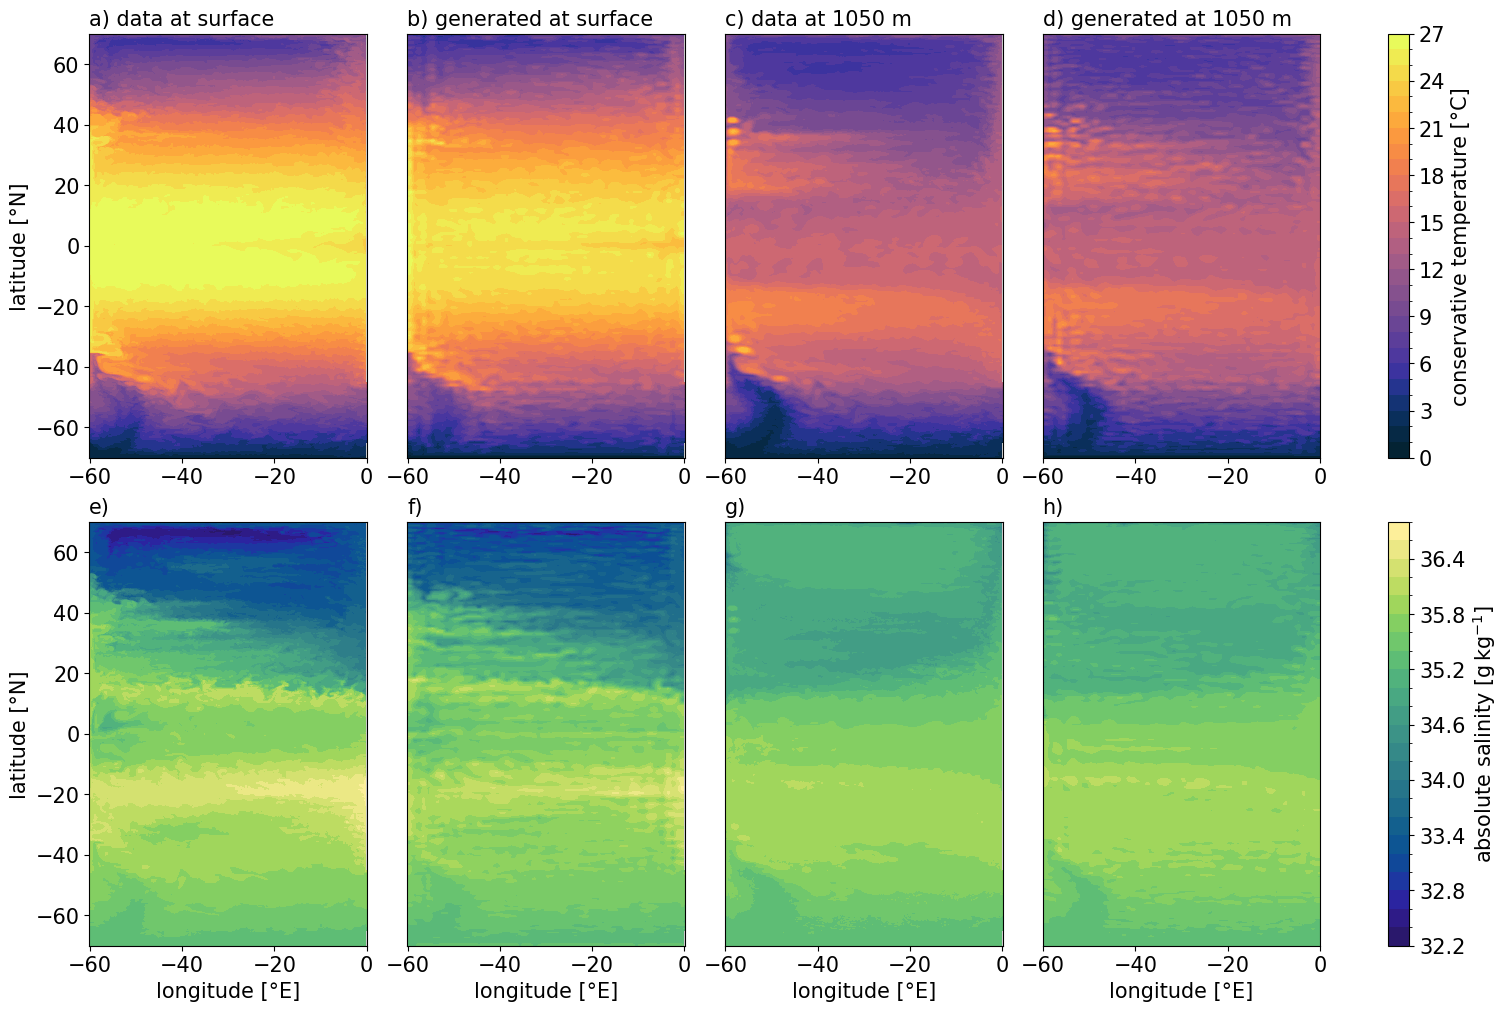

In [115]:
fig_toce, axs = plt.subplots(2,4, figsize=(15,10), constrained_layout=True)#, sharex=True)

a = t_r.isel(z_c=0).where(exp_1_4ref.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=28, vmin=0, vmax=27, cmap=cm.thermal, y='gphit', x='lon_n', ax=axs[0,0], add_colorbar=False)
b = t_c.isel(z_c=0).where(exp_1_4ref.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=28, vmin=0, vmax=27, cmap=cm.thermal, y='lat', x='lon_n', ax=axs[0,1], add_colorbar=False)

c = t_r.isel(z_c=17).where(exp_1_4ref.mask.tmask.isel(z_c=25)==1.0).plot.contourf(levels=28, vmin=0, vmax=27, cmap=cm.thermal, y='gphit', x='lon_n', ax=axs[0,2], add_colorbar=False)
d = t_c.isel(z_c=17).where(exp_1_4ref.mask.tmask.isel(z_c=25)==1.0).plot.contourf(levels=28, vmin=0, vmax=27, cmap=cm.thermal, y='lat', x='lon_n', ax=axs[0,3], add_colorbar=False)


e = s_r.isel(z_c=0).where(exp_1_4ref.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=24, vmin=32.2, vmax=36.8, cmap=cm.haline, y='gphit', x='lon_n', ax=axs[1,0], add_colorbar=False)
f = s_c.isel(z_c=0).where(exp_1_4ref.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=24, vmin=32.2, vmax=36.8, cmap=cm.haline, y='lat', x='lon_n', ax=axs[1,1], add_colorbar=False)

g = s_r.isel(z_c=17).where(exp_1_4ref.mask.tmask.isel(z_c=25)==1.0).plot.contourf(levels=24, vmin=32.2, vmax=36.8, cmap=cm.haline, y='gphit', x='lon_n', ax=axs[1,2], add_colorbar=False)
h = s_c.isel(z_c=17).where(exp_1_4ref.mask.tmask.isel(z_c=25)==1.0).plot.contourf(levels=24, vmin=32.2, vmax=36.8, cmap=cm.haline, y='lat', x='lon_n', ax=axs[1,3], add_colorbar=False)

#MLD_mean_4.where(exp_4.mask.tmask.isel(z_c=0)==1.0).plot.contour(levels=19, colors='k', linewidths=0.75, vmin=0, vmax=900, y='gphit', x='glamt', ax=axs[1])
# = MLD_mean_16.where(exp_16.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=19, vmin=0, vmax=900, cmap=cm.cm.deep, y='gphit', x='glamt', ax=axs[2], add_colorbar=False)
#MLD_mean_16.where(exp_16.mask.tmask.isel(z_c=0)==1.0).plot.contour(levels=19, colors='k', linewidths=0.75, vmin=0, vmax=900, y='gphit', x='glamt', ax=axs[2])
cbar1 = fig_toce.colorbar(a, ax=axs[0,:4], label=r'conservative temperature [°C]')
cbar2 = fig_toce.colorbar(e, ax=axs[1,:4], label=r'absolute salinity [$\text{g} \, \text{kg}^{-1}$]')
axs[0,1].set_ylabel(' ')
axs[1,1].set_ylabel(' ')
axs[0,2].set_ylabel(' ')
axs[1,2].set_ylabel(' ')
axs[0,3].set_ylabel(' ')
axs[1,3].set_ylabel(' ')
axs[0,0].set_ylabel('latitude [°N]')
axs[1,0].set_ylabel('latitude [°N]')
axs[1,0].set_xlabel('longitude [°E]')
axs[1,1].set_xlabel('longitude [°E]')
axs[1,2].set_xlabel('longitude [°E]')
axs[1,3].set_xlabel('longitude [°E]')
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('')
axs[0,2].set_xlabel('')
axs[0,3].set_xlabel('')
axs[0,1].set_yticks([])
axs[1,1].set_yticks([])
axs[0,2].set_yticks([])
axs[1,2].set_yticks([])
axs[0,3].set_yticks([])
axs[1,3].set_yticks([])
axs[0,0].set_title('')
axs[0,1].set_title('')
axs[0,2].set_title('')
axs[0,3].set_title('')
axs[1,0].set_title('')
axs[1,1].set_title('')
axs[1,2].set_title('')
axs[1,3].set_title('')
axs[0,0].set_title('a) data at surface', loc='left')
axs[0,1].set_title('b) generated at surface', loc='left')
axs[0,2].set_title('c) data at 1050 m', loc='left')
axs[0,3].set_title('d) generated at 1050 m', loc='left')
axs[1,0].set_title('e)', loc='left')
axs[1,1].set_title('f)', loc='left')
axs[1,2].set_title('g)', loc='left')
axs[1,3].set_title('h)', loc='left')
axs[0,0].set_facecolor("lightgray")
axs[0,1].set_facecolor("lightgray")
axs[0,2].set_facecolor("lightgray")
axs[0,3].set_facecolor("lightgray")
axs[1,0].set_facecolor("lightgray")
axs[1,1].set_facecolor("lightgray")
axs[1,2].set_facecolor("lightgray")
axs[1,3].set_facecolor("lightgray")


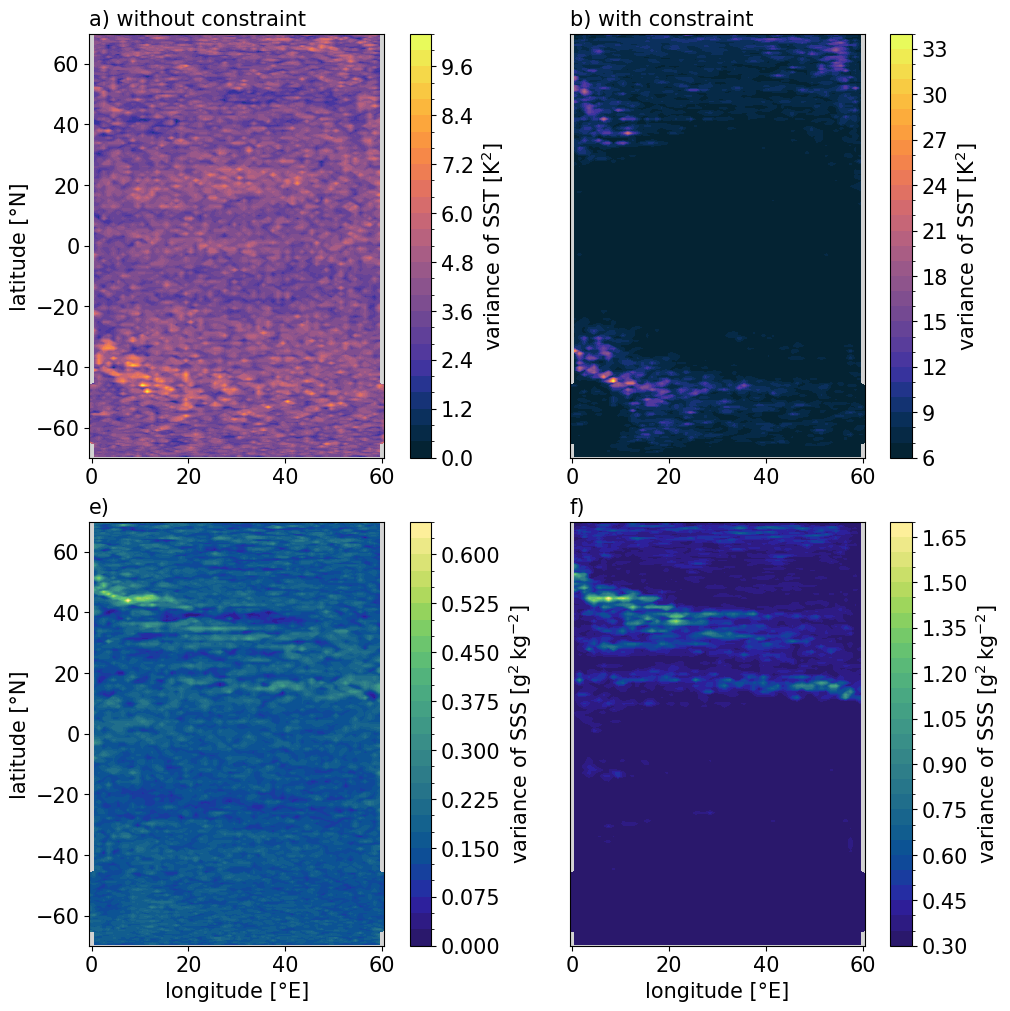

In [54]:
fig_var, axs = plt.subplots(2,2, figsize=(10,10), constrained_layout=True)#, sharex=True)

a = restart_dummy.var_t_c.where(exp_1deg.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=30, cmap=cm.cm.thermal, y='gphit', x='glamt', ax=axs[0,1], add_colorbar=False)
b = restart_dummy.var_t_u.where(exp_1deg.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=30, cmap=cm.cm.thermal, y='gphit', x='glamt', ax=axs[0,0], add_colorbar=False)

c = restart_dummy.var_s_c.where(exp_1deg.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=30, cmap=cm.cm.haline, y='gphit', x='glamt', ax=axs[1,1], add_colorbar=False)
d = restart_dummy.var_s_u.where(exp_1deg.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=30, cmap=cm.cm.haline, y='gphit', x='glamt', ax=axs[1,0], add_colorbar=False)


#MLD_mean_4.where(exp_4.mask.tmask.isel(z_c=0)==1.0).plot.contour(levels=19, colors='k', linewidths=0.75, vmin=0, vmax=900, y='gphit', x='glamt', ax=axs[1])
# = MLD_mean_16.where(exp_16.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=19, vmin=0, vmax=900, cmap=cm.cm.deep, y='gphit', x='glamt', ax=axs[2], add_colorbar=False)
#MLD_mean_16.where(exp_16.mask.tmask.isel(z_c=0)==1.0).plot.contour(levels=19, colors='k', linewidths=0.75, vmin=0, vmax=900, y='gphit', x='glamt', ax=axs[2])
cbar1 = fig_var.colorbar(a, ax=axs[0,0], label=r'variance of SST [$\text{K}^{2}$]')
cbar2 = fig_var.colorbar(b, ax=axs[0,1], label=r'variance of SST [$\text{K}^{2}$]')

cbar3 = fig_var.colorbar(c, ax=axs[1,0], label=r'variance of SSS [$\text{g}^{2} \, \text{kg}^{-2}$]')
cbar4 = fig_var.colorbar(d, ax=axs[1,1], label=r'variance of SSS [$\text{g}^{2} \, \text{kg}^{-2}$]')

#cbar2 = fig_var.colorbar(c, ax=axs[1,:4], label=r'absolute salinity [$\text{g} \, \text{kg}^{-1}$]')
axs[0,1].set_ylabel(' ')
axs[1,1].set_ylabel(' ')
axs[0,0].set_ylabel('latitude [°N]')
axs[1,0].set_ylabel('latitude [°N]')
axs[1,0].set_xlabel('longitude [°E]')
axs[1,1].set_xlabel('longitude [°E]')
axs[0,0].set_xlabel('')
axs[0,1].set_xlabel('')
axs[0,1].set_yticks([])
axs[1,1].set_yticks([])
axs[0,0].set_title('')
axs[0,1].set_title('')
axs[1,0].set_title('')
axs[1,1].set_title('')
axs[0,0].set_title('a) without constraint', loc='left')
axs[0,1].set_title('b) with constraint', loc='left')
axs[1,0].set_title('e)', loc='left')
axs[1,1].set_title('f)', loc='left')
axs[0,0].set_facecolor("lightgray")
axs[0,1].set_facecolor("lightgray")
axs[1,0].set_facecolor("lightgray")
axs[1,1].set_facecolor("lightgray")

In [46]:
restart_dummy.var_t_c.where(exp_1deg.mask.tmask.isel(z_c=0)==1.0)

<xarray.DataArray 'var_t_c' (y_c: 199, x_c: 62)>
dask.array<where, shape=(199, 62), dtype=float32, chunksize=(199, 62), chunktype=numpy.ndarray>
Coordinates:
  * x_c       (x_c) int64 0 1 2 3 4 5 6 7 8 9 ... 52 53 54 55 56 57 58 59 60 61
  * y_c       (y_c) int64 0 1 2 3 4 5 6 7 8 ... 191 192 193 194 195 196 197 198
    glamt     (y_c, x_c) float64 dask.array<chunksize=(199, 62), meta=np.ndarray>
    gphit     (y_c, x_c) float64 dask.array<chunksize=(199, 62), meta=np.ndarray>
    gdept_1d  float64 dask.array<chunksize=(), meta=np.ndarray>
    gdept_0   (y_c, x_c) float64 dask.array<chunksize=(199, 62), meta=np.ndarray>
    z_c       int64 0

In [89]:
exp_1_4ref.mask.gdept_1d.isel(z_c=25).values

array(1057.40732172)

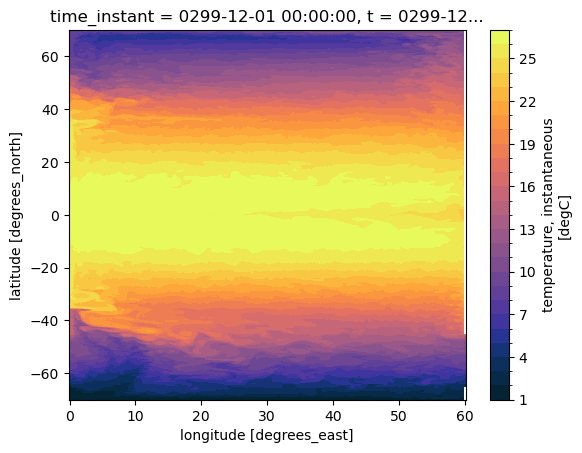

In [45]:
a = t_r.isel(z_c=0).where(exp_1_4ref.mask.tmask.isel(z_c=0)==1.0).plot.contourf(levels=28, cmap=cm.thermal, y='gphit', x='glamt')#, add_colorbar=False)

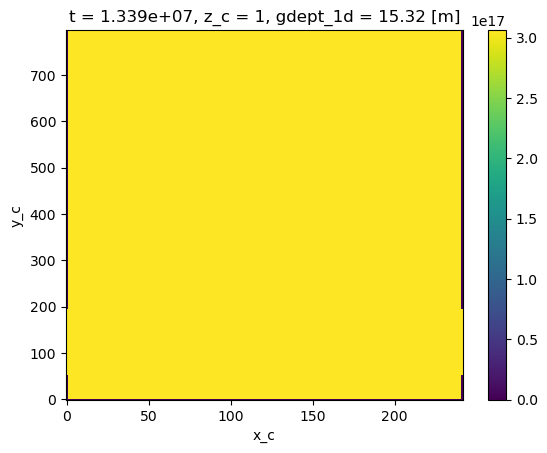

In [188]:
((sigma2_u.diff('z_c') <0.0 ) * V).isel(z_c=0).plot()

In [186]:
unstable_u.values

array([6.159017e+23], dtype=float32)

In [182]:
V.values

array(3.0621928e+17, dtype=float32)

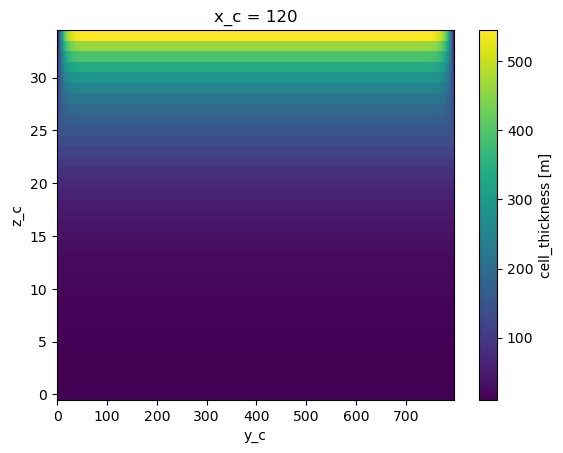

In [167]:
exp_1_4con.mask.e3t_0.isel(z_c=slice(0,-1)).isel(x_c=120).plot()

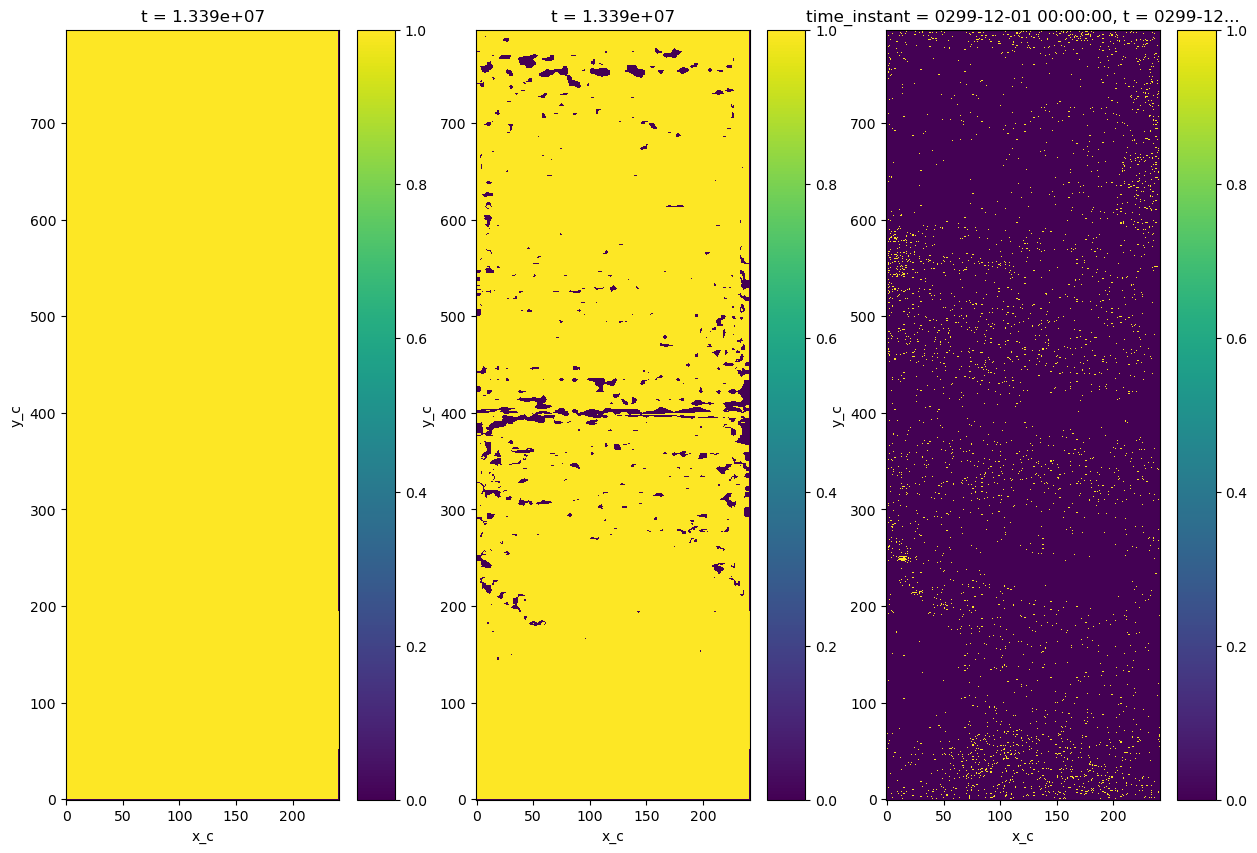

In [146]:
fig, axs = plt.subplots(1,3, figsize=(15,10))
(sigma2_u.diff('z_c').min('z_c')).plot(ax=axs[0])
(sigma2_c.diff('z_c').min('z_c')).plot(ax=axs[1])
(sigma2_4_r.isel(t=-1).differentiate('z_c').min('z_c')).plot(ax=axs[2])

axs[0].set_title('')
axs[1].set_title('')
axs[2].set_title('')

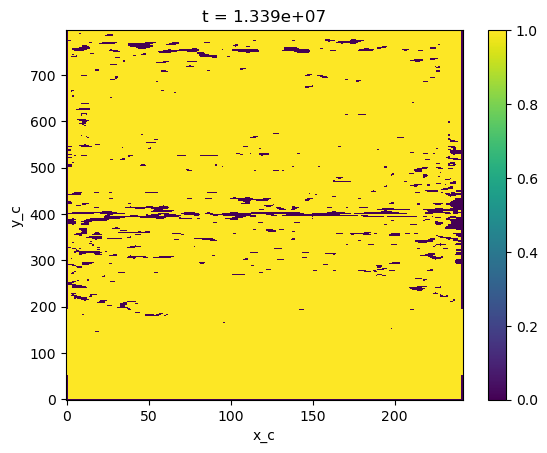

In [144]:
(sigma2_c.diff('z_c').min('z_c')<-0.00).plot()

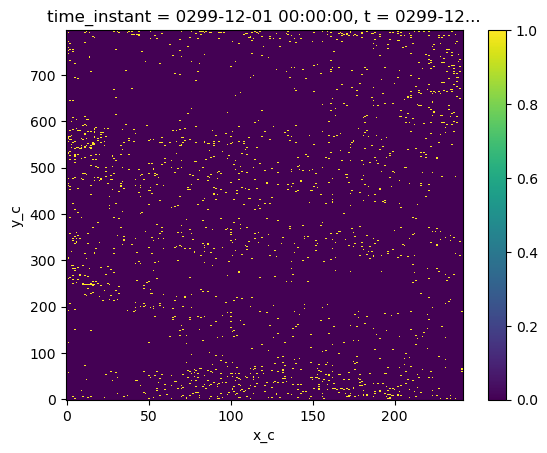

In [143]:
(sigma2_4_r.isel(t=-1).diff('z_c').min('z_c')<-0.00).plot()

In [146]:
toce_ref = exp_1_4ref.data['T_3D'].toce_inst.isel(z_c=-2,t=slice(-180,None)).mean(['y_c', 'x_c']).compute()
soce_ref = exp_1_4ref.data['T_3D'].soce_inst.isel(z_c=-2,t=slice(-180,None)).mean(['y_c', 'x_c']).compute()

In [151]:
t_ref = toce_ref.mean('t').values
s_ref = soce_ref.mean('t').values

In [144]:
toce_con = exp_1_4con.data['inst_T_3D'].toce_inst.isel(z_c=-2).mean(['y_c', 'x_c']).compute()
toce_uncon = exp_1_4uncon.data['inst_T_3D'].toce_inst.isel(z_c=-2).mean(['y_c', 'x_c']).compute()

In [141]:
soce_con = exp_1_4con.data['inst_T_3D'].soce_inst.isel(z_c=-2).mean(['y_c', 'x_c']).compute()
soce_uncon = exp_1_4uncon.data['inst_T_3D'].soce_inst.isel(z_c=-2).mean(['y_c', 'x_c']).compute()

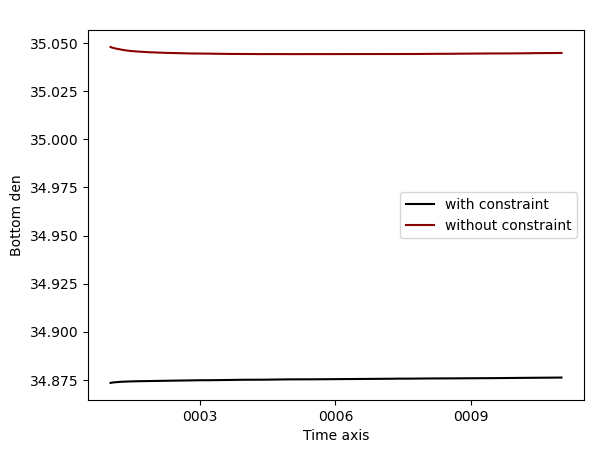

In [142]:
soce_con.plot(color='black', label='with constraint')
soce_uncon.plot(color='darkred', label='without constraint')
plt.ylabel('Bottom den')
plt.title(' ')
plt.legend()

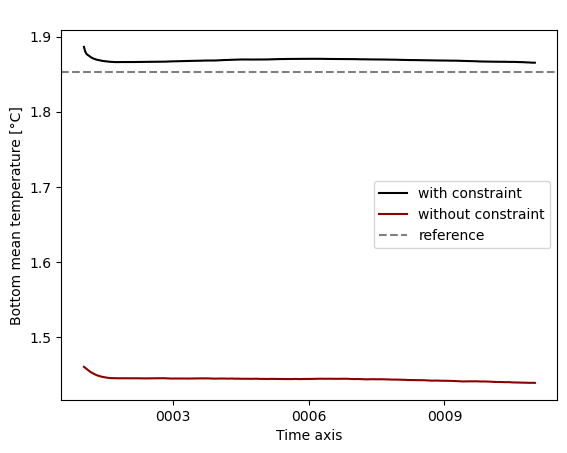

In [155]:
toce_con.plot(color='black', label='with constraint')
toce_uncon.plot(color='darkred', label='without constraint')
plt.axhline(y=t_ref, color='grey', linestyle='--', label='reference')
plt.ylabel('Bottom mean temperature [°C]')
plt.title(' ')
plt.legend()

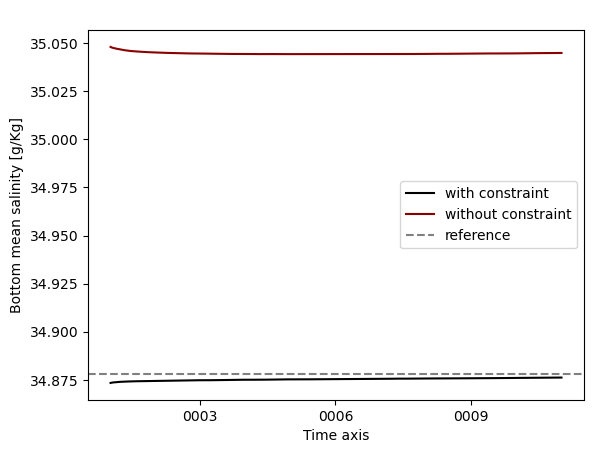

In [154]:
soce_con.plot(color='black', label='with constraint')
soce_uncon.plot(color='darkred', label='without constraint')
plt.axhline(y=s_ref, color='grey', linestyle='--', label='reference')
plt.ylabel('Bottom mean salinity [g/Kg]')
plt.title(' ')
plt.legend()

In [110]:
ACC_uncon = exp_1_4uncon.diagnostics.get_ACC().compute()

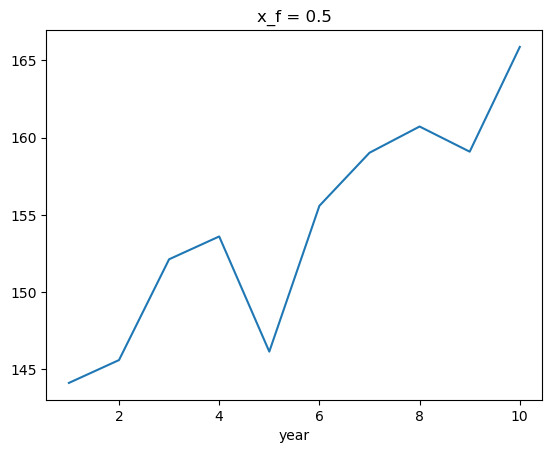

In [113]:
ACC_uncon.groupby('t.year').mean().plot()

In [119]:
exp_1_4ref.data['U_3D']

In [116]:
ACC_ref = (exp_1_4ref.data['inst_U_3D'].uoce.isel(x_f=0) * domain.e3u_0.isel(x_f=0) * domain.e2u.isel(x_f=0)).sum(['y_c', 'z_c']) / 1e6

U_3D data not available.


AttributeError: 'NoneType' object has no attribute 'compute'

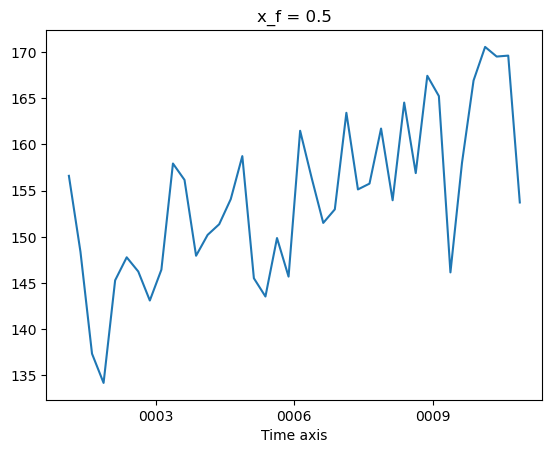

In [114]:
ACC_uncon.plot()

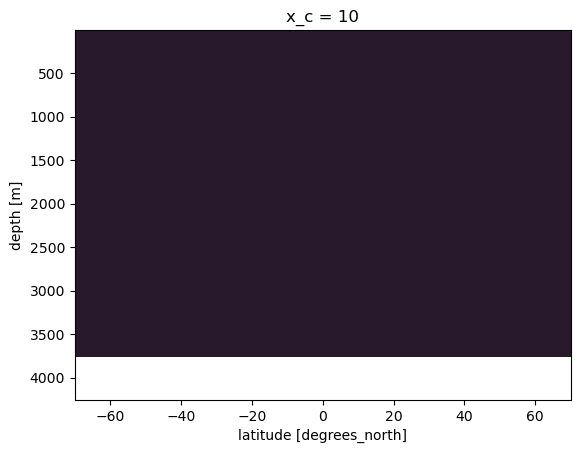

In [61]:
sigma2_4_ref.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', add_colorbar=False, yincrease=False)

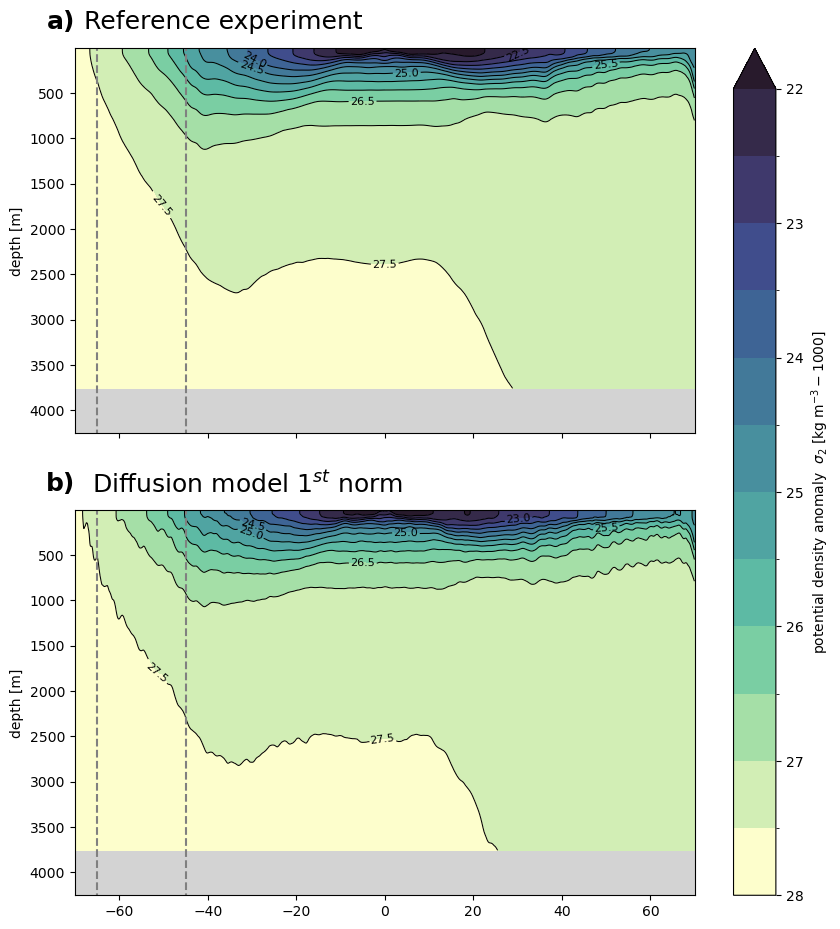

In [25]:
fig_dense, axs = plt.subplots(2,1, figsize=(10,11), sharex=True, sharey=True)
#fig, axs = plt.subplots(3,1, figsize=(15,11), sharex=True, sharey=True)
levels = np.linspace(22.,28.,13)
a = sigma2_4_ref.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[0], add_colorbar=False, yincrease=False)
contour_1 = sigma2_4_ref.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#sigma2_1.plot.contour(levels=13, colors='k', linewidths=0.75, vmin=1025.6, vmax=1028, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
#b = sigma2_4.isel(t=slice(0,4)).mean('t').plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[1], add_colorbar=False, yincrease=False)
#contour_2 = sigma2_4.isel(t=slice(0,4)).mean('t').plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[1], yincrease=False)
#plt.clabel(contour_2, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
c = sigma2_4_new.isel(t=0).plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[1], add_colorbar=False, yincrease=False)
contour_3 = sigma2_4_new.isel(t=0).plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[1], yincrease=False)
plt.clabel(contour_3, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#c = moc_16.isel(t=slice(-17,-1)).mean('t').plot.contourf(levels=16, vmin=-15, vmax=15, cmap=cm.cm.balance, x='y_f', y='rho', ax=axs[2], add_colorbar=False, yincrease=False)
#moc_16.isel(t=slice(-41,-1)).mean('t').plot.contour(levels=16, colors='k', linewidths=0.75, vmin=-15, vmax=15, x='y_f', y='rho', ax=axs[2], yincrease=False)
cbar1 = fig_dense.colorbar(a, ax=axs[:3], label=r'potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
axs[1].set_ylabel(r'depth [m]')
axs[0].set_ylabel(r'depth [m]')
axs[1].set_xlabel('')
axs[0].set_xlabel('')

axs[0].set_title(' ')
axs[1].set_title(' ')
axs[0].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[0].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
#plt.subplots_adjust(hspace=0.1)
axs[0].set_facecolor("lightgray")
axs[1].set_facecolor("lightgray")
axs[0].text(-0.0, 1.1, 'a)', transform=axs[0].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[0].text(0.465, 1.1, 'Reference experiment', transform=axs[0].transAxes, fontsize=18, va='top', ha='right')
axs[1].text(-0.0, 1.1, 'b)', transform=axs[1].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[1].text(0.53, 1.1, r'Diffusion model $1^{st}$ norm', transform=axs[1].transAxes, fontsize=18, va='top', ha='right')
cbar1.ax.invert_yaxis()

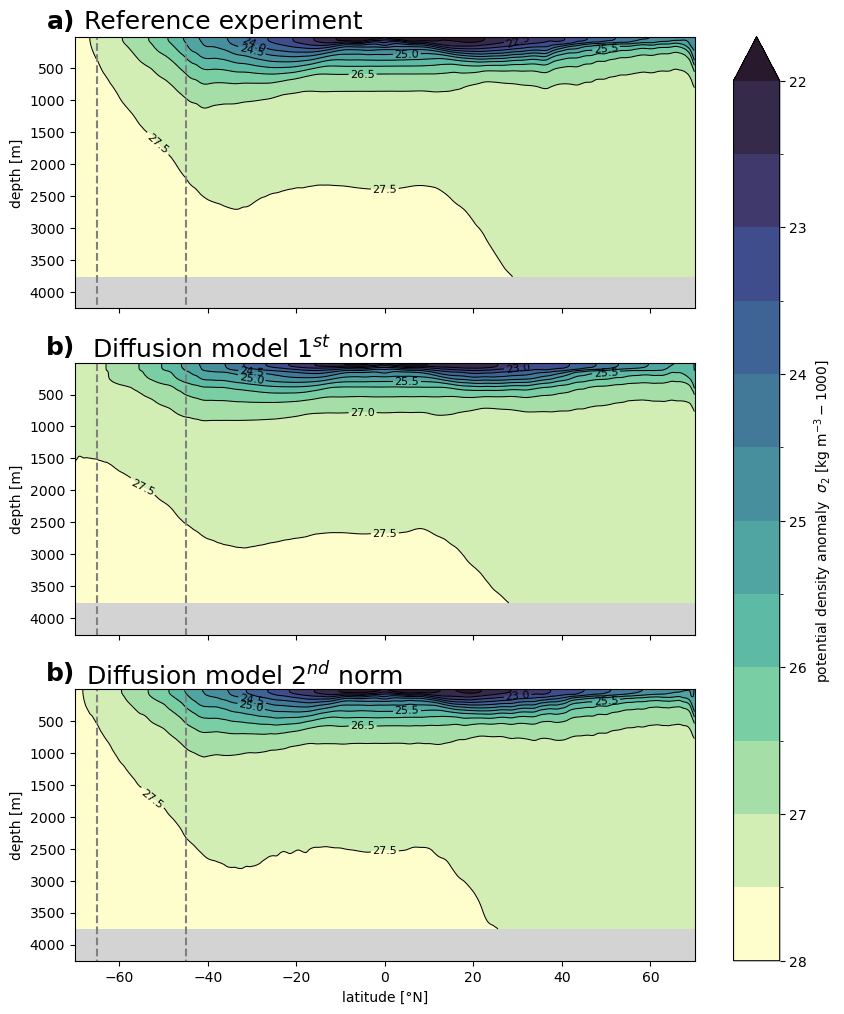

In [18]:
fig_dense, axs = plt.subplots(3,1, figsize=(10,12), sharex=True, sharey=True)
#fig, axs = plt.subplots(3,1, figsize=(15,11), sharex=True, sharey=True)
levels = np.linspace(22.,28.,13)
a = sigma2_4_ref.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[0], add_colorbar=False, yincrease=False)
contour_1 = sigma2_4_ref.plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#sigma2_1.plot.contour(levels=13, colors='k', linewidths=0.75, vmin=1025.6, vmax=1028, x='lat', y='gdept_1d', ax=axs[0], yincrease=False)
b = sigma2_4.isel(t=slice(0,4)).mean('t').plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[1], add_colorbar=False, yincrease=False)
contour_2 = sigma2_4.isel(t=slice(0,4)).mean('t').plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[1], yincrease=False)
plt.clabel(contour_2, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
c = sigma2_4_new.isel(t=slice(0,4)).mean('t').plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat', y='gdept_1d', ax=axs[2], add_colorbar=False, yincrease=False)
contour_3 = sigma2_4_new.isel(t=slice(0,4)).mean('t').plot.contour(levels=levels, colors='k', linewidths=0.75, x='lat', y='gdept_1d', ax=axs[2], yincrease=False)
plt.clabel(contour_3, fmt="%.1f", inline=True, fontsize=8, manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (-30,200)])
#c = moc_16.isel(t=slice(-17,-1)).mean('t').plot.contourf(levels=16, vmin=-15, vmax=15, cmap=cm.cm.balance, x='y_f', y='rho', ax=axs[2], add_colorbar=False, yincrease=False)
#moc_16.isel(t=slice(-41,-1)).mean('t').plot.contour(levels=16, colors='k', linewidths=0.75, vmin=-15, vmax=15, x='y_f', y='rho', ax=axs[2], yincrease=False)
cbar1 = fig_dense.colorbar(a, ax=axs[:3], label=r'potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
axs[1].set_ylabel(r'depth [m]')
axs[0].set_ylabel(r'depth [m]')
axs[2].set_ylabel(r'depth [m]')
axs[2].set_xlabel('latitude [°N]')
axs[1].set_xlabel('')
axs[0].set_xlabel('')

axs[0].set_title(' ')
axs[1].set_title(' ')
axs[2].set_title(' ')
axs[0].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[0].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[1].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[2].axvline(x=-65, ymin=4000, ymax=0, color='gray', linestyle='dashed')
axs[2].axvline(x=-45, ymin=4000, ymax=0, color='gray', linestyle='dashed')
#plt.subplots_adjust(hspace=0.1)
axs[0].set_facecolor("lightgray")
axs[1].set_facecolor("lightgray")
axs[2].set_facecolor("lightgray")
axs[0].text(-0.0, 1.1, 'a)', transform=axs[0].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[0].text(0.465, 1.1, 'Reference experiment', transform=axs[0].transAxes, fontsize=18, va='top', ha='right')
axs[1].text(-0.0, 1.1, 'b)', transform=axs[1].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[1].text(0.53, 1.1, r'Diffusion model $1^{st}$ norm', transform=axs[1].transAxes, fontsize=18, va='top', ha='right')
axs[1].text(-0.0, 1.1, 'c)', transform=axs[2].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[1].text(0.53, 1.1, r'Diffusion model $2^{nd}$ norm', transform=axs[2].transAxes, fontsize=18, va='top', ha='right')
cbar1.ax.invert_yaxis()

In [110]:
diff = (sigma2_4 - sigma2_4_ref).isel(y_c=52).assign_coords({'years':('t',np.arange(0.25,10.25,0.25))})

Text(0.5, 1.0, '')

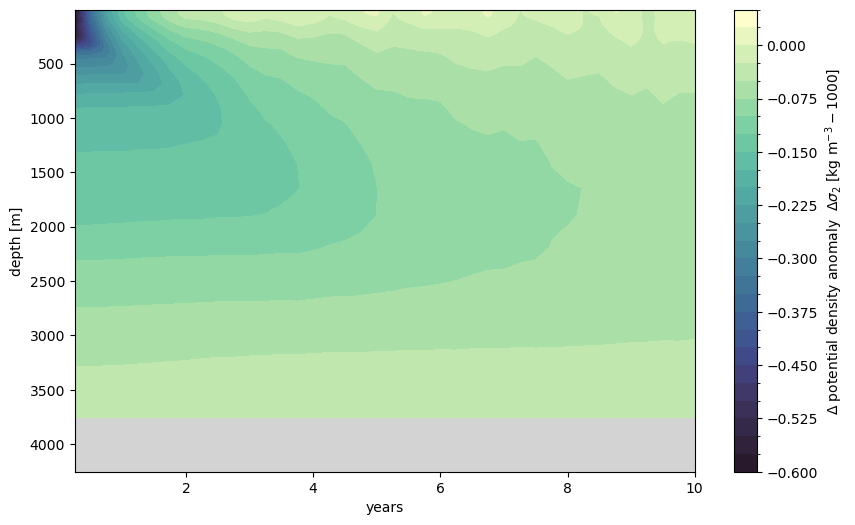

In [123]:
fig_evolution, axs = plt.subplots(1,1, figsize=(10,6))
a = diff.plot.contourf(levels=27,x='years', y='gdept_1d', yincrease=False, cmap=cm.cm.deep_r, vmin=-0.6, vmax=0.05, add_colorbar=False)
axs.set_facecolor("lightgray")
cbar1 = fig_dense.colorbar(a, ax=axs, label=r'$\Delta$ potential density anomaly  $\Delta \sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
axs.set_title('')

In [116]:
fig_dense.savefig('./Diffusion_model_rho.pdf', format='pdf', dpi=600, bbox_inches='tight')

In [117]:
fig_dense_gen.savefig('./Diffusion_model_rho_gen.pdf', format='pdf', dpi=600, bbox_inches='tight')

In [118]:
fig_toce.savefig('./Diffusion_model_state.pdf', format='pdf', dpi=600, bbox_inches='tight')

In [55]:
fig_var.savefig('./Diffusion_model_variance.pdf', format='pdf', dpi=600, bbox_inches='tight')

In [125]:
fig_evolution.savefig('./Diffusion_model_time.pdf', format='pdf', dpi=600, bbox_inches='tight')